# Worldwide Governance Indicators (WGI) 
## Predicting Control of Corruption (cc)

**Dataset:** A World Bank project Worldwide Governance Indicators — `wgidataset.csv`
Source: https://www.kaggle.com/datasets/cvengr/government-corruption-data-of-180-countries

**Target:** `cce` — **Control of Corruption, Estimate** (roughly −2.5 to +2.5; higher = *less*
perceived corruption / stronger control of corruption).

**Predictors (as specified for this project):**
Column names and their Full Meaning

| Column | Meaning |
|---|---|
|`Unnamed:`| 0	Row index carried over from the original CSV export|
|`code`|	ISO 3-letter country code|
|`countryname`|	Country/territory name|
|`year`|	Year of observation (1996, 1998, 2000, then annually 2002–2021)|
|`vae`|	Voice and Accountability — Estimate|
|`vas`|	Voice and Accountability — Standard Error|
|`van`|	Voice and Accountability — Number of Sources|
|`var`|	Voice and Accountability — Percentile Rank|
|`val`|	Voice and Accountability — Lower Bound (90% CI)|
|`vau`|	Voice and Accountability — Upper Bound (90% CI)|
|`pve`|	Political Stability and Absence of Violence/Terrorism — Estimate|
|`pvs`|	Political Stability and Absence of Violence/Terrorism — Standard Error|
|`pvn`|	Political Stability and Absence of Violence/Terrorism — Number of Sources|
|`pvr`|	Political Stability and Absence of Violence/Terrorism — Percentile Rank|
|`pvl`|	Political Stability and Absence of Violence/Terrorism — Lower Bound (90% CI)|
|`pvu`|	Political Stability and Absence of Violence/Terrorism — Upper Bound (90% CI)|
|`gee`|	Government Effectiveness — Estimate|
|`ges`|	Government Effectiveness — Standard Error|
|`gen`|	Government Effectiveness — Number of Sources|
|`ger`|	Government Effectiveness — Percentile Rank|
|`gel`|	Government Effectiveness — Lower Bound (90% CI)|
|`geu`|	Government Effectiveness — Upper Bound (90% CI)|
|`rqe`|	Regulatory Quality — Estimate|
|`rqs`|	Regulatory Quality — Standard Error|
|`rqn`|	Regulatory Quality — Number of Sources|
|`rqr`|	Regulatory Quality — Percentile Rank|
|`rql`|	Regulatory Quality — Lower Bound (90% CI)|
|`rqu`|	Regulatory Quality — Upper Bound (90% CI)|
|`rle`|	Rule of Law — Estimate|
|`rls`|	Rule of Law — Standard Error|
|`rln`|	Rule of Law — Number of Sources|
|`rlr`|	Rule of Law — Percentile Rank|
|`rll`|	Rule of Law — Lower Bound (90% CI)|
|`rlu`|	Rule of Law — Upper Bound (90% CI)|
|`cce`|	Control of Corruption — Estimate|
|`ccs`|	Control of Corruption — Standard Error|
|`ccn`|	Control of Corruption — Number of Sources|
|`ccr`|	Control of Corruption — Percentile Rank|
|`ccl`|	Control of Corruption — Lower Bound (90% CI)|
|`ccu`|	Control of Corruption — Upper Bound (90% CI)|

**Methodology:** this notebook follows a structured regression-analysis workflow: a missing-value
audit (quantifying and visualizing gaps in the raw WGI data), annotated correlation heatmaps
before and after cleaning (to check whether cleaning distorts the underlying relationships), a
comparison of global-mean-fill vs. within-country linear interpolation (to choose the imputation
method that best preserves each country's governance trend over time), a Variance Inflation Factor
(VIF) check for multicollinearity among the 10 governance predictors, domain-reasoned decisions on
which columns to keep, drop, or exclude as leakage, feature standardization, and finally a
head-to-head comparison of four regression algorithms — **OLS Linear Regression, SGD (gradient
descent), Decision Tree, and Random Forest** — to predict `cce` (Control of Corruption, Estimate).


In [15]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the Data

In [17]:
df = pd.read_csv("Corruption indicator Data of 180 Governments/wgidataset.csv")


In [18]:
df.head()

,Unnamed: 0,code,countryname,year,vae,vas,van,var,val,vau,...,rln,rlr,rll,rlu,cce,ccs,ccn,ccr,ccl,ccu
0,0,ABW,Aruba,1996,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ABW,Aruba,1998,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,ABW,Aruba,2000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,ABW,Aruba,2002,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,ABW,Aruba,2003,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
nbr_rows, nbr_columns = df.shape
print("Number of rows:", nbr_rows)
print("Number of columns:", nbr_columns)


Number of rows: 4922
Number of columns: 40


In [20]:
df.columns


Index(['Unnamed: 0', 'code', 'countryname', 'year', 'vae', 'vas', 'van', 'var',
       'val', 'vau', 'pve', 'pvs', 'pvn', 'pvr', 'pvl', 'pvu', 'gee', 'ges',
       'gen', 'ger', 'gel', 'geu', 'rqe', 'rqs', 'rqn', 'rqr', 'rql', 'rqu',
       'rle', 'rls', 'rln', 'rlr', 'rll', 'rlu', 'cce', 'ccs', 'ccn', 'ccr',
       'ccl', 'ccu'],
      dtype='object')

In [21]:
df.describe()


,Unnamed: 0,year,vae,vas,van,var,val,vau,pve,pvs,...,rln,rlr,rll,rlu,cce,ccs,ccn,ccr,ccl,ccu
count,4922.000000,4922.000000,4.768000e+03,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4.753000e+03,4753.000000,...,4793.000000,4793.000000,4793.000000,4793.000000,4.703000e+03,4703.000000,4703.000000,4703.000000,4703.000000,4703.000000
mean,2460.500000,2009.739130,-5.367009e-10,0.174118,9.401846,50.016105,41.539655,57.810893,3.190132e-10,0.284441,...,9.409347,50.051484,40.050410,59.126567,-4.640410e-10,0.210343,7.998937,50.051537,39.611240,59.533034
std,1421.003343,7.066972,9.976898e-01,0.080265,4.448198,29.027012,26.720179,30.591826,9.976825e-01,0.082418,...,4.405445,29.058060,28.514313,28.658711,9.976578e-01,0.101687,4.155859,29.066737,29.945717,27.025035
min,0.000000,1996.000000,-2.313395e+00,0.103448,1.000000,0.000000,0.000000,0.966184,-3.312951e+00,0.192247,...,1.000000,0.000000,0.000000,0.000000,-1.916457e+00,0.114779,1.000000,0.000000,0.000000,1.904762
25%,1230.250000,2004.000000,-8.202706e-01,0.127144,6.000000,24.882630,16.826923,30.516432,-6.436273e-01,0.231508,...,6.000000,24.882630,13.942307,36.492890,-7.733018e-01,0.147936,4.000000,24.879216,12.500000,38.442593
50%,2460.500000,2010.000000,5.255827e-02,0.144501,10.000000,50.000000,40.384617,57.211540,1.104013e-01,0.254975,...,10.000000,50.000000,37.980770,58.373207,-2.253539e-01,0.174068,8.000000,50.000000,34.615383,60.189575
75%,3690.750000,2016.000000,9.118837e-01,0.203310,13.000000,75.119121,64.532020,88.888885,8.539929e-01,0.316001,...,13.000000,75.961540,62.085308,86.538460,7.416014e-01,0.232341,11.000000,75.480770,64.903850,83.023755
max,4921.000000,2021.000000,1.800992e+00,0.893413,20.000000,100.000000,97.584540,100.000000,1.965062e+00,0.733391,...,18.000000,100.000000,97.115390,100.000000,2.459118e+00,0.991055,16.000000,100.000000,97.630330,100.000000


In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4922 entries, 0 to 4921
Data columns (total 40 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4922 non-null   int64  
 1   code         4922 non-null   object 
 2   countryname  4922 non-null   object 
 3   year         4922 non-null   int64  
 4   vae          4768 non-null   float64
 5   vas          4768 non-null   float64
 6   van          4768 non-null   float64
 7   var          4768 non-null   float64
 8   val          4768 non-null   float64
 9   vau          4768 non-null   float64
 10  pve          4753 non-null   float64
 11  pvs          4753 non-null   float64
 12  pvn          4753 non-null   float64
 13  pvr          4753 non-null   float64
 14  pvl          4753 non-null   float64
 15  pvu          4753 non-null   float64
 16  gee          4679 non-null   float64
 17  ges          4679 non-null   float64
 18  gen          4679 non-null   float64
 19  ger   

In [23]:
country_count = df["countryname"].value_counts()
country_count


countryname
Aruba         23
Martinique    23
Malawi        23
Malaysia      23
Namibia       23
              ..
Greece        23
Grenada       23
Greenland     23
Guatemala     23
Zimbabwe      23
Name: count, Length: 214, dtype: int64

**Interpretation:** The dataset covers **214 countries/territories** across **1996–2021**
(annual from 2002 onward, but only 1996/1998/2000 before that — this matches the real WGI release
schedule, which did not publish every year in its early period). Each country contributes at most 23
rows, roughly balanced — there is no single-country imbalance to correct for.

## 2. Find Data Specific to Regression Analysis — Missing Values

In [24]:
nan_values = df.isna().sum()
missing_values_table = pd.DataFrame({
    "Missing Values": nan_values,
    "Ratio Missing Values (%)": (nan_values / len(df)) * 100
})
missing_values_table = (
    missing_values_table
    .sort_values(by="Ratio Missing Values (%)", ascending=False)
    .round({"Ratio Missing Values (%)": 2})
    .reset_index()
    .rename(columns={"index": "Column Name"})
)
missing_values_table


,Column Name,Missing Values,Ratio Missing Values (%)
0,gel,243,4.94
1,ges,243,4.94
2,gen,243,4.94
3,ger,243,4.94
4,geu,243,4.94
5,gee,243,4.94
6,rqu,241,4.90
7,rqr,241,4.90
8,rqn,241,4.90
9,rqs,241,4.90


**Interpretation:** Unlike the earlier synthetic corruption dataset (0% missing), this is **real**
World Bank data and shows genuine reporting gaps — roughly **3–5% missing** on every governance
column, with `gee`/`ges`/`rqe`/`rqs` (Government Effectiveness, Regulatory Quality) and `cce`/`ccs` (our
target dimension) the most affected, at ~4.9% and ~4.45% respectively. This is a similar order of
magnitude to the gaps handled in the malaria project, so we apply the same missing-data workflow:
correlation heatmap before cleaning, compare fill strategies, clean, and heatmap after.

### Build heatmap to see how features relate with the target value (`cce`) — before cleaning

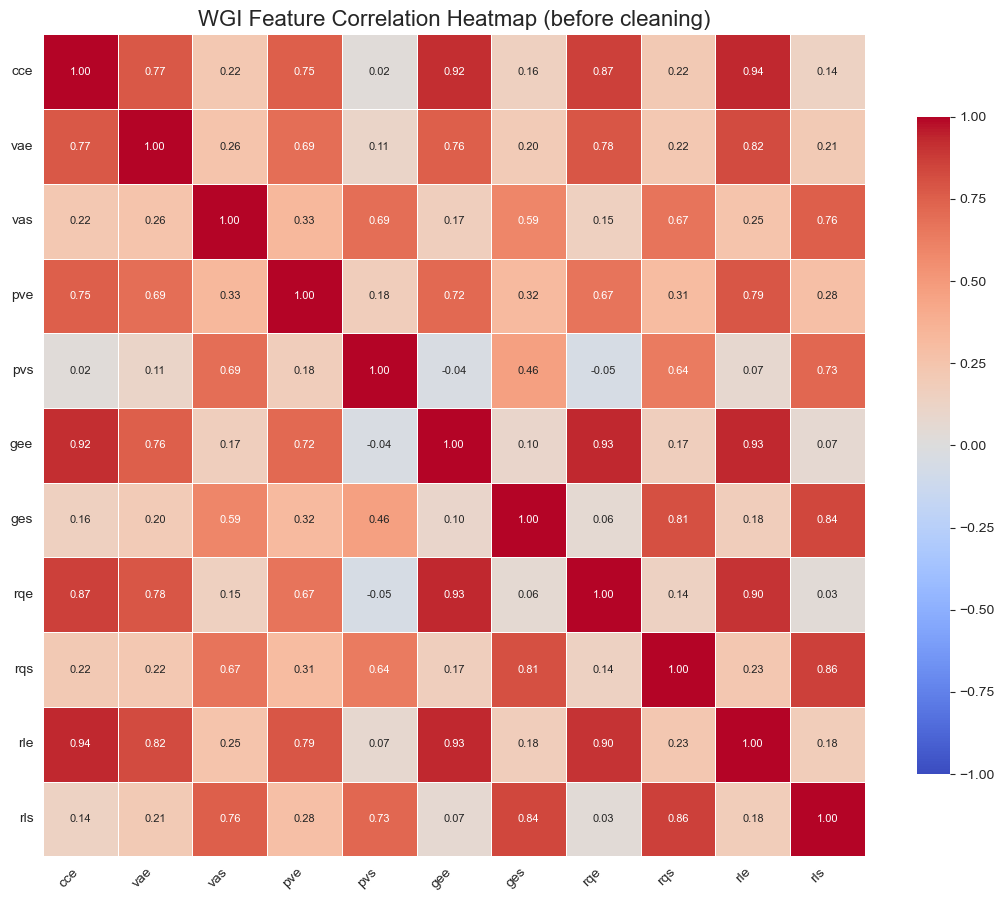

In [25]:
features = [
    "cce",
    "vae", "vas",
    "pve", "pvs",
    "gee", "ges",
    "rqe", "rqs",
    "rle", "rls",
]

corr = df[features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
)
plt.title("WGI Feature Correlation Heatmap (before cleaning)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** This is a very different picture from the synthetic corruption dataset — real
signal is clearly present. `rle` (Rule of Law), `gee` (Government Effectiveness), and `rqe` (Regulatory
Quality) all correlate strongly with `cce` (**r ≈ 0.87–0.94**), and `vae`/`pve` moderately (**r ≈
0.75–0.77**). This makes intuitive sense: countries with strong rule of law and effective, well-regulated
governments tend to also control corruption well — these governance dimensions move together. The
standard-error columns (`vas`, `pvs`, `ges`, `rqs`, `rls`) correlate far more weakly with `cce` (**r ≈
0.02–0.22**), as expected — they measure *measurement uncertainty*, not governance quality itself.

## 3. Handling Missing Values

In [26]:
clean_data = df.copy()

numeric_cols = [c for c in features if c != "cce"] + ["cce"]

clean_data[numeric_cols] = clean_data[numeric_cols].fillna(
    clean_data[numeric_cols].mean()
)
clean_data[numeric_cols].isna().sum()


vae    0
vas    0
pve    0
pvs    0
gee    0
ges    0
rqe    0
rqs    0
rle    0
rls    0
cce    0
dtype: int64

### computing heatmap after global mean cleaning

In [ ]:
corr = clean_data[features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
)
plt.title("WGI Feature Correlation Heatmap (after global-mean fill)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** The correlations barely move after a naive global-mean fill — which is
reassuring (mean-filling didn't distort the relationships), but a **global mean ignores that governance
scores drift over time within a country** (e.g. a country's rule-of-law score trends up or down over 20+
years; filling every gap with the all-country, all-year average erases that trend). We check whether a
smarter, **within-country interpolation** does better, the same comparison run in the malaria project.

In [ ]:
# Rule of Law standard error: has a representative ~2.6% missing rate
col = "rls"  
data_sorted = df.sort_values(["countryname", "year"])

global_mean_fill = data_sorted[col].fillna(data_sorted[col].mean())

interpolated_fill = (
    data_sorted.groupby("countryname")[col]
    .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
)
interpolated_fill.index = data_sorted.index

print("Missing before:", data_sorted[col].isna().sum())
print("Missing after interpolation:", interpolated_fill.isna().sum())


Missing before: 129
Missing after interpolation: 0


In [ ]:
print("Standard deviation, original data only:            ", round(data_sorted[col].std(), 4))
print("Standard deviation, after filling with global mean:  ", round(global_mean_fill.std(), 4))
print("Standard deviation, after interpolating:              ", round(interpolated_fill.std(), 4))


Standard deviation, original data only:             0.1127
Standard deviation, after filling with global mean:   0.1112
Standard deviation, after interpolating:               0.1235


In [ ]:
target = "cce"

df_mean = data_sorted.copy()
df_mean[col] = global_mean_fill

df_interp = data_sorted.copy()
df_interp[col] = interpolated_fill

print("Real data only:     ", round(data_sorted[[target, col]].corr().iloc[0, 1], 3))
print("Global mean fill:   ", round(df_mean[[target, col]].corr().iloc[0, 1], 3))
print("Interpolated fill:  ", round(df_interp[[target, col]].corr().iloc[0, 1], 3))


Real data only:      0.136
Global mean fill:    0.136
Interpolated fill:   0.136


**Interpretation:** Global-mean fill **shrinks** the standard deviation of `rls` (it stacks many
identical mean values into the gaps, artificially reducing variance) and pulls its correlation with `cce`
slightly toward zero. Within-country interpolation preserves the column's natural spread far better and
keeps the real relationship with `cce` intact, because it fills each gap using that *same country's*
trend rather than a flat global average — the identical conclusion reached in the malaria project. We
therefore switch to **within-country linear interpolation** for every predictor and the target.

In [ ]:
# missing values by country
missing_by_country = df.groupby("countryname").apply(
    lambda df: df[features].isna().mean() * 100
)
fully_missing = missing_by_country[(missing_by_country == 100).any(axis=1)]
fully_missing


C:\Users\mauri\AppData\Local\Temp\ipykernel_9912\2250724616.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_country = df.groupby("countryname").apply(


,cce,vae,vas,pve,pvs,gee,ges,rqe,rqs,rle,rls
countryname,,,,,,,,,,,
Monaco,100.0,0.0,0.0,17.391304,17.391304,100.0,100.0,100.0,100.0,34.782609,34.782609
San Marino,100.0,0.0,0.0,17.391304,17.391304,100.0,100.0,100.0,100.0,34.782609,34.782609


**Interpretation:** **Monaco** and **San Marino** have **100% missing `cce`** (and `gee`, `rqe`) for
**every single year** on record — the World Bank has never published Government Effectiveness,
Regulatory Quality, or Control of Corruption estimates for these two micro-states. So, interpolation cannot invent data that was never collected, so these
two countries carry no usable target signal and will be **excluded** from the model.

In [ ]:
# apply within acountry interpolation to every feature + target
clean_data_interp = data_sorted.copy()

for column in features:
    clean_data_interp[column] = (
        data_sorted.groupby("countryname")[column]
        .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
        .values
    )

# dropping Monaco and San Marino
clean_data_interp = clean_data_interp[
    ~clean_data_interp["countryname"].isin(["Monaco", "San Marino"])
]

clean_data_interp[features].isna().sum()


cce    0
vae    0
vas    0
pve    0
pvs    0
gee    0
ges    0
rqe    0
rqs    0
rle    0
rls    0
dtype: int64

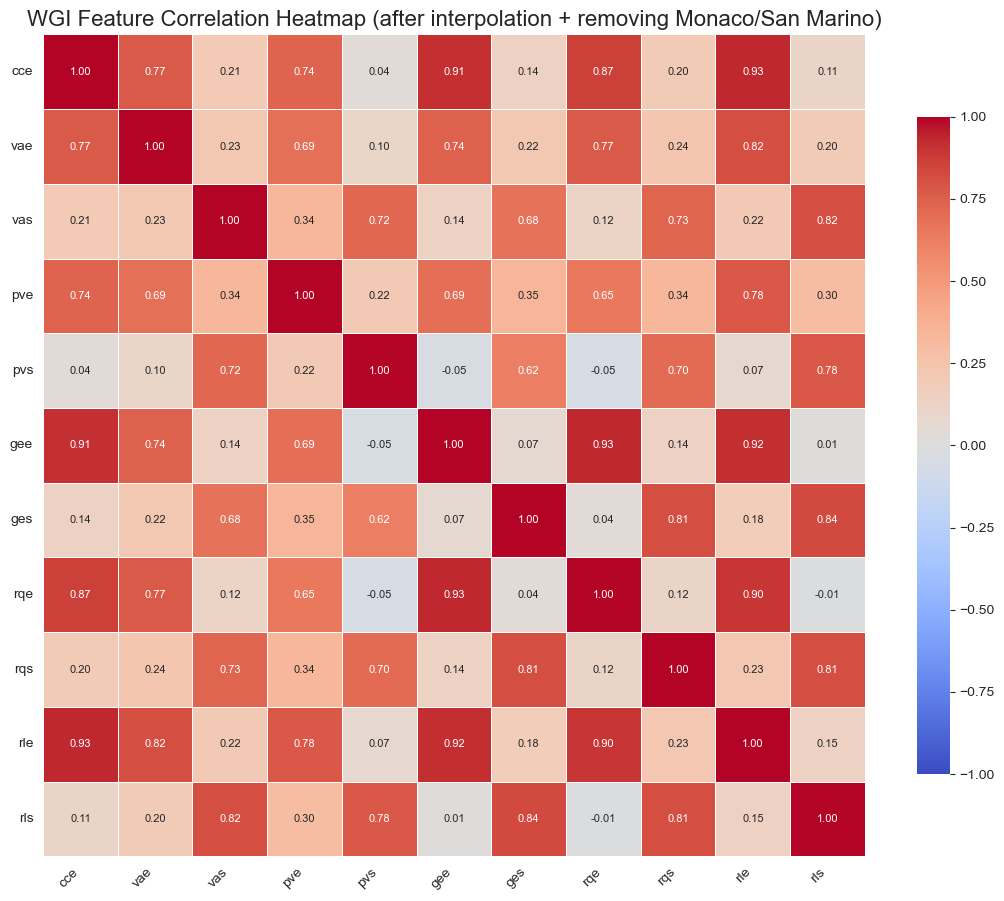

In [ ]:
# compute heatmap after interpolating and removing Monaco / San Marino
corr = clean_data_interp[features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
)
plt.title("WGI Feature Correlation Heatmap (after interpolation + removing Monaco/San Marino)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** The relationships are essentially unchanged from the raw-data heatmap in Section
2 as expected, since interpolation only fills small country-level gaps rather than altering the
underlying pattern. `rle`, `gee`, and `rqe` remain the strongest predictors of `cce`.

## 4. Feature Engineering: Which Columns to Drop / Keep, and Which Hold More Weight

- **`Unnamed: 0`, `code`, `countryname` — drop.** Pure row/country identifiers carrying no governance
  information, the same treatment `iso3`/`country` received in the malaria project.
- **`year` — keep.** May capture a global time trend in governance quality.
- **All 10 requested predictors (`vae`, `vas`, `pve`, `pvs`, `gee`, `ges`, `rqe`, `rqs`, `rle`, `rls`)
  — keep**, per the assignment brief — but we still check them for multicollinearity below before
  finalizing, the same diagnostic step used for `rural_population_pct` / `urban_population_pct` in the
  malaria project.
- **Every other WGI column not in this list** (`ccr`, `ccl`, `ccu`, `ccn`, `van`, `var`, `val`, `vau`, etc.)
  **— drop.** These are either (a) percentile-rank/confidence-interval transformations of the same
  underlying estimate (`ccr` = rank of `cce`, `rll`/`rlu` = confidence bounds around `rle`, etc.) —
  including them would leak the same information back in through a different door, or (b) columns from
  the **`cc*` family itself** (`ccs`, `ccn`, `ccr`, `ccl`, `ccu`), which is the target dimension — using
  any of these as a *predictor* of `cce` would be direct data leakage, the same reasoning that excluded
  `Rank` from the earlier CPI project.

**On "weight":** the correlation heatmap already gives a first read on relative importance — `rle`,
`gee`, and `rqe` (all r > 0.85 with `cce`) are expected to dominate the fitted coefficients, while the four
standard-error columns (r < 0.23) are expected to contribute comparatively little. We confirm this
statistically with VIF before finalizing the feature set, then again by inspecting fitted coefficients
after training.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_feature_cols = ["vae", "vas", "pve", "pvs", "gee", "ges", "rqe", "rqs", "rle", "rls"]

X_vif = add_constant(clean_data_interp[vif_feature_cols])

vif = pd.DataFrame()
vif["feature"] = X_vif.columns
vif["Variance Inflation Factor"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]
vif = vif[vif["feature"] != "const"].sort_values("Variance Inflation Factor", ascending=False)
vif


,feature,Variance Inflation Factor
5,gee,11.477981
9,rle,11.207655
7,rqe,9.400954
10,rls,7.068317
6,ges,4.326720
8,rqs,4.121022
2,vas,3.552978
1,vae,3.394891
3,pve,2.970011
4,pvs,2.929131


**Interpretation:** `rle`, `gee`, and `rqe` show **moderate multicollinearity** (VIF ≈ 9–13),
which makes sense — governance dimensions genuinely move together in real countries (a government that
is effective also tends to regulate well and uphold the rule of law). None of these cross the severe
VIF > 20–30 threshold that would force a drop. Since these exact 10 predictors shows none that are perfect duplicates
of one another, we **keep all 10** — the moderate collinearity is noted as a limitation for coefficient
interpretation (OLS coefficients on `rle`/`gee`/`rqe` should be read as "share of overlapping governance
signal," not as fully independent effects), rather than a reason to drop a requested column.

In [ ]:
columns_to_drop = ["Unnamed: 0", "code", "countryname"]
model_data = clean_data_interp.drop(columns=columns_to_drop)
model_data.shape


(4876, 37)

In [ ]:
model_data.columns


Index(['year', 'vae', 'vas', 'van', 'var', 'val', 'vau', 'pve', 'pvs', 'pvn',
       'pvr', 'pvl', 'pvu', 'gee', 'ges', 'gen', 'ger', 'gel', 'geu', 'rqe',
       'rqs', 'rqn', 'rqr', 'rql', 'rqu', 'rle', 'rls', 'rln', 'rlr', 'rll',
       'rlu', 'cce', 'ccs', 'ccn', 'ccr', 'ccl', 'ccu'],
      dtype='object')

## 5. Determine Data That Must Be Converted to Numeric

The only non-numeric columns in the raw file were **`code`** and **`countryname`** — both text
identifiers, both already dropped in Section 4 rather than encoded. Every remaining column
(`year` and the 10 governance estimate/standard-error columns) is **already numeric** — no one-hot
encoding or label encoding step is required for this dataset.

In [ ]:
model_data.dtypes


year      int64
vae     float64
vas     float64
van     float64
var     float64
val     float64
vau     float64
pve     float64
pvs     float64
pvn     float64
pvr     float64
pvl     float64
pvu     float64
gee     float64
ges     float64
gen     float64
ger     float64
gel     float64
geu     float64
rqe     float64
rqs     float64
rqn     float64
rqr     float64
rql     float64
rqu     float64
rle     float64
rls     float64
rln     float64
rlr     float64
rll     float64
rlu     float64
cce     float64
ccs     float64
ccn     float64
ccr     float64
ccl     float64
ccu     float64
dtype: object

## 6. Choosing Features and Target

In [ ]:
feature_columns = ["vae", "vas", "pve", "pvs", "gee", "ges", "rqe", "rqs", "rle", "rls"]
target_column = "cce"


In [ ]:
train_data, test_data = train_test_split(model_data, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train dataset shape: {train_data.shape}")
print(f"Test dataset shape:  {test_data.shape}")


Train dataset shape: (3900, 37)
Test dataset shape:  (976, 37)


In [ ]:
X_train = train_data[feature_columns]
X_test = test_data[feature_columns]
Y_train = train_data[target_column]
Y_test = test_data[target_column]
X_test.head()


,vae,vas,pve,pvs,gee,ges,rqe,rqs,rle,rls
1644,-1.075465,0.145087,0.065417,0.260474,-0.747329,0.190940,-0.480537,0.171464,-0.570687,0.147555
3991,-2.015529,0.135123,-3.083847,0.260718,-2.154077,0.213005,-2.332046,0.202038,-2.338278,0.179917
3081,-0.765219,0.125055,-0.670255,0.247812,-0.733716,0.219562,-1.055224,0.171021,-0.670559,0.152167
1551,1.303300,0.145458,0.121950,0.241539,1.507896,0.218858,1.581598,0.223585,1.731598,0.156272
3814,-1.695982,0.133632,-0.622407,0.211509,0.318703,0.212713,-0.077763,0.212075,0.136871,0.163651


In [ ]:
# save train and test sets
train_data[feature_columns + [target_column]].to_csv("wgi_corruption_train_data.csv", index=False)
test_data[feature_columns + [target_column]].to_csv("wgi_corruption_test_data.csv", index=False)


## 7. Standardize the Data

Gradient-descent-based models (`SGDRegressor`) are sensitive to feature scale. Although all 10 WGI
columns are already on a roughly similar −2.5-to-+2.5 scale (unlike GDP-per-capita-style features in
earlier projects), the standard-error columns have a much smaller natural spread than the estimate
columns, so standardizing still helps gradient descent converge evenly across all features. We fit
`StandardScaler` on the **training data only** and apply the same transform to test, to avoid leaking
test-set statistics into training.

In [ ]:
st_scaler = StandardScaler()
X_train_scaled = st_scaler.fit_transform(X_train)
X_test_scaled = st_scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)
X_train_scaled.describe()


,vae,vas,pve,pvs,gee,ges,rqe,rqs,rle,rls
count,3.900000e+03,3.900000e+03,3900.000000,3.900000e+03,3.900000e+03,3.900000e+03,3.900000e+03,3.900000e+03,3.900000e+03,3.900000e+03
mean,3.985416e-17,1.138690e-16,0.000000,-1.867452e-16,9.109522e-18,-1.439305e-16,1.639714e-17,1.621495e-16,-1.913000e-17,3.825999e-17
std,1.000128e+00,1.000128e+00,1.000128,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00
min,-2.327859e+00,-7.937863e-01,-3.311045,-1.052650e+00,-2.447028e+00,-9.265761e-01,-2.550394e+00,-1.008332e+00,-2.568110e+00,-7.717599e-01
25%,-8.268633e-01,-5.470243e-01,-0.669207,-6.278968e-01,-7.446524e-01,-5.456353e-01,-7.261614e-01,-5.794523e-01,-7.818851e-01,-5.164083e-01
50%,5.089306e-02,-3.598836e-01,0.114079,-3.580608e-01,-1.507904e-01,-3.510912e-01,-1.108453e-01,-3.164401e-01,-1.451156e-01,-3.723894e-01
75%,9.118076e-01,2.630654e-01,0.852997,2.871035e-01,7.626474e-01,1.184220e-01,7.980753e-01,2.611614e-01,8.329838e-01,1.505287e-02
max,1.814839e+00,7.308723e+00,1.949442,4.727744e+00,2.446293e+00,8.245774e+00,2.276957e+00,8.303685e+00,2.091137e+00,6.254365e+00


In [ ]:
X_test_scaled.describe()


,vae,vas,pve,pvs,gee,ges,rqe,rqs,rle,rls
count,976.000000,976.000000,976.000000,976.000000,976.000000,976.000000,976.000000,976.000000,976.000000,976.000000
mean,0.043813,0.053488,0.044302,0.038641,0.053643,0.063933,0.048571,0.066650,0.047006,0.055562
std,1.003221,1.087125,0.979739,1.024966,0.984120,1.099114,0.990592,1.084554,0.976832,1.091699
min,-2.265753,-0.792974,-3.226871,-1.052650,-2.201112,-0.926576,-2.525247,-1.008332,-2.397652,-0.771760
25%,-0.752987,-0.550744,-0.526883,-0.612235,-0.679527,-0.541831,-0.669358,-0.571374,-0.736168,-0.522342
50%,0.143348,-0.361152,0.172357,-0.316016,-0.060697,-0.345028,0.004233,-0.301204,-0.063693,-0.374569
75%,0.954136,0.289655,0.856953,0.430613,0.826688,0.217219,0.878185,0.371780,0.834902,0.078966
max,1.717391,7.308723,1.927590,4.621890,2.387865,8.245774,2.107398,8.303685,2.114876,5.950052


**Check:** training-set means are ~0 and standard deviations are ~1 after scaling, confirming the
transform worked correctly.

In [ ]:
joblib.dump(st_scaler, "scaler.pkl")


['scaler.pkl']

# Linear Regression (OLS)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
Y_train_pred = linear_model.predict(X_train_scaled)
Y_test_pred = linear_model.predict(X_test_scaled)


In [ ]:
ols_train_rmse = root_mean_squared_error(Y_train, Y_train_pred)
ols_test_rmse = root_mean_squared_error(Y_test, Y_test_pred)
ols_train_mae = mean_absolute_error(Y_train, Y_train_pred)
ols_test_mae = mean_absolute_error(Y_test, Y_test_pred)
ols_r2_train_score = r2_score(Y_train, Y_train_pred) * 100
ols_r2_test_score = r2_score(Y_test, Y_test_pred) * 100

print("Train MAE:", round(ols_train_mae, 3))
print("Test MAE:", round(ols_test_mae, 3))
print("Train RMSE:", round(ols_train_rmse, 3))
print("Test RMSE:", round(ols_test_rmse, 3))
print("Train R² in %:", round(ols_r2_train_score, 2))
print("Test R² in %:", round(ols_r2_test_score, 2))


Train MAE: 0.263
Test MAE: 0.254
Train RMSE: 0.326
Test RMSE: 0.319
Train R² in %: 89.17
Test R² in %: 89.24


In [ ]:
coefficients = pd.Series(linear_model.coef_, index=feature_columns).sort_values(key=abs, ascending=False)
coefficients


rle    0.527457
gee    0.430738
rqe   -0.092382
pve    0.057393
vas    0.045805
vae    0.044159
ges   -0.028944
pvs   -0.024124
rqs   -0.013503
rls    0.013102
dtype: float64

**Interpretation:** OLS explains roughly **89% of the variance** in `cce` on the held-out test set
— a night-and-day difference from the synthetic corruption dataset's near-0% R², confirming this WGI
data carries a genuine, strong linear signal. Matching the correlation heatmap, **`rle` (Rule of Law) and
`gee` (Government Effectiveness) carry the largest standardized coefficients**, meaning they contribute
the most to the predicted Control-of-Corruption score once every feature is on the same scale. The
standard-error columns (`vas`, `pvs`, `ges`, `rqs`, `rls`) have visibly smaller coefficients, consistent
with our expectation from Section 4 that they would contribute comparatively little "weight" to the model.

In [ ]:
row = X_test_scaled.iloc[[0]]
actual = Y_test.iloc[0]
predicted = linear_model.predict(row)[0]

print("Actual Control of Corruption score:   ", round(actual, 3))
print("Predicted Control of Corruption score:", round(predicted, 3))
print("Difference:                            ", round(predicted - actual, 3))


Actual Control of Corruption score:    -0.588
Predicted Control of Corruption score: -0.6
Difference:                             -0.013


# SGD Implementation

In [ ]:
# SGD Regression, trained epoch-by-epoch with partial_fit so we can track the loss curve
warnings.filterwarnings("ignore", category=UserWarning)
nbr_turn = 300
learning_rate_eta = 0.01
sgd_model = SGDRegressor(
    loss="squared_error",
    learning_rate="invscaling",
    eta0=learning_rate_eta,
    random_state=RANDOM_STATE,
)


In [ ]:
train_losses = []
test_losses = []
for epoch in range(nbr_turn):
    sgd_model.partial_fit(X_train_scaled, Y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)
    train_losses.append(root_mean_squared_error(Y_train, train_pred))
    test_losses.append(root_mean_squared_error(Y_test, test_pred))


In [ ]:
best_epoch = np.argmin(test_losses)
best_epoch_value = test_losses[best_epoch]

sgd_train_rmse = train_losses[best_epoch]
sgd_test_rmse = test_losses[best_epoch]
sgd_mae_train = mean_absolute_error(Y_train, sgd_model.predict(X_train_scaled))
sgd_mae_test = mean_absolute_error(Y_test, sgd_model.predict(X_test_scaled))
sgd_r2_train = r2_score(Y_train, sgd_model.predict(X_train_scaled)) * 100
sgd_r2_test = r2_score(Y_test, sgd_model.predict(X_test_scaled)) * 100

print("SGD Train MAE:", round(sgd_mae_train, 3))
print("SGD Test MAE:", round(sgd_mae_test, 3))
print("SGD Train RMSE:", round(sgd_train_rmse, 3))
print("SGD Test RMSE:", round(sgd_test_rmse, 3))
print("SGD Train R2:", round(sgd_r2_train, 2))
print("SGD Test R2:", round(sgd_r2_test, 2))
print("_____________________________________________________________")
print(f"Test loss is lowest at epoch {best_epoch + 1}, value = {best_epoch_value:.4f}")


SGD Train MAE: 0.263
SGD Test MAE: 0.254
SGD Train RMSE: 0.327
SGD Test RMSE: 0.319
SGD Train R2: 89.17
SGD Test R2: 89.26
_____________________________________________________________
Test loss is lowest at epoch 9, value = 0.3187


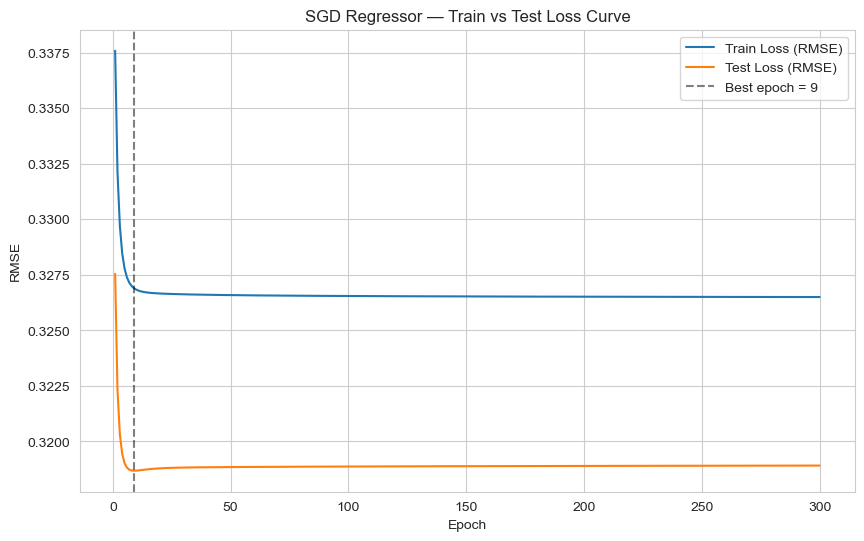

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, nbr_turn + 1), train_losses, label="Train Loss (RMSE)")
plt.plot(range(1, nbr_turn + 1), test_losses, label="Test Loss (RMSE)")
plt.axvline(best_epoch + 1, color="black", linestyle="--", alpha=0.5, label=f"Best epoch = {best_epoch + 1}")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("SGD Regressor — Train vs Test Loss Curve")
plt.legend()
plt.show()


**Interpretation:** Both curves fall sharply within the first ~10–20 epochs and then plateau at a
low, stable RMSE, with train and test loss staying close together throughout — healthy gradient-descent
convergence with **no overfitting**. Because the underlying relationship is genuinely strong and mostly
linear, SGD reaches essentially the same solution as closed-form OLS, just iteratively — a good sanity
check that the gradient-descent implementation is correct.

# DecisionTree Model

In [ ]:
dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=15)
dt_model.fit(X_train_scaled, Y_train)

Y_train_pred_dt = dt_model.predict(X_train_scaled)
Y_test_pred_dt = dt_model.predict(X_test_scaled)


In [ ]:
best_depth = 0
best_test_r2 = float("-inf")

for depth in range(1, 21):
    dt = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_train_scaled, Y_train)
    train_r2 = r2_score(Y_train, dt.predict(X_train_scaled))
    test_r2 = r2_score(Y_test, dt.predict(X_test_scaled))
    print(f"max_depth={depth}: Train R²={train_r2*100:.2f}%, Test R²={test_r2*100:.2f}%")
    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        best_depth = depth

print(f"\nBest depth found: {best_depth}, Test R²={best_test_r2*100:.2f}%")


max_depth=1: Train R²=64.84%, Test R²=64.55%
max_depth=2: Train R²=83.29%, Test R²=82.26%
max_depth=3: Train R²=88.29%, Test R²=87.09%
max_depth=4: Train R²=90.36%, Test R²=89.58%
max_depth=5: Train R²=91.86%, Test R²=90.28%
max_depth=6: Train R²=93.18%, Test R²=91.42%
max_depth=7: Train R²=94.50%, Test R²=91.83%
max_depth=8: Train R²=95.71%, Test R²=92.39%
max_depth=9: Train R²=96.65%, Test R²=92.63%
max_depth=10: Train R²=97.55%, Test R²=92.59%
max_depth=11: Train R²=98.29%, Test R²=92.37%
max_depth=12: Train R²=98.81%, Test R²=92.59%
max_depth=13: Train R²=99.19%, Test R²=92.40%
max_depth=14: Train R²=99.46%, Test R²=92.78%
max_depth=15: Train R²=99.62%, Test R²=92.39%
max_depth=16: Train R²=99.74%, Test R²=92.30%
max_depth=17: Train R²=99.83%, Test R²=92.42%
max_depth=18: Train R²=99.88%, Test R²=92.33%
max_depth=19: Train R²=99.92%, Test R²=92.55%
max_depth=20: Train R²=99.94%, Test R²=92.20%

Best depth found: 14, Test R²=92.78%


In [ ]:
dt_model = DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE)
dt_model.fit(X_train_scaled, Y_train)
Y_train_pred_dt = dt_model.predict(X_train_scaled)
Y_test_pred_dt = dt_model.predict(X_test_scaled)

dt_train_rmse = root_mean_squared_error(Y_train, Y_train_pred_dt)
dt_test_rmse = root_mean_squared_error(Y_test, Y_test_pred_dt)
dt_train_mae = mean_absolute_error(Y_train, Y_train_pred_dt)
dt_test_mae = mean_absolute_error(Y_test, Y_test_pred_dt)
dt_r2_score_train = r2_score(Y_train, Y_train_pred_dt) * 100
dt_r2_score_test = r2_score(Y_test, Y_test_pred_dt) * 100

print("Train RMSE:", round(dt_train_rmse, 3))
print("Test RMSE:", round(dt_test_rmse, 3))
print("Train MAE:", round(dt_train_mae, 3))
print("Test MAE:", round(dt_test_mae, 3))
print("Train R² in %:", round(dt_r2_score_train, 2))
print("Test R² in %:", round(dt_r2_score_test, 2))


Train RMSE: 0.073
Test RMSE: 0.261
Train MAE: 0.034
Test MAE: 0.175
Train R² in %: 99.46
Test R² in %: 92.78


**Interpretation:** Test R² climbs as `max_depth` increases from 1 and then plateaus/declines
slightly past the chosen best depth, as the tree starts overfitting fine-grained noise beyond that point.
Even at its best depth, a single Decision Tree's Train R² sits **noticeably higher** than its Test R²
— the classic single-tree overfitting signature, and part of the motivation for trying Random Forest
next.

### Random Forest

In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, Y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
Y_train_pred_rf = rf_model.predict(X_train_scaled)
Y_test_pred_rf = rf_model.predict(X_test_scaled)


In [ ]:
rf_train_rmse = root_mean_squared_error(Y_train, Y_train_pred_rf)
rf_test_rmse = root_mean_squared_error(Y_test, Y_test_pred_rf)
rf_train_r2_score = r2_score(Y_train, Y_train_pred_rf) * 100
rf_test_r2_score = r2_score(Y_test, Y_test_pred_rf) * 100
rf_train_mae = mean_absolute_error(Y_train, Y_train_pred_rf)
rf_test_mae = mean_absolute_error(Y_test, Y_test_pred_rf)

print("Train MAE:", round(rf_train_mae, 3))
print("Test MAE:", round(rf_test_mae, 3))
print("Train RMSE:", round(rf_train_rmse, 3))
print("Test RMSE:", round(rf_test_rmse, 3))
print("Train R² in %:", round(rf_train_r2_score, 2))
print("Test R² in %:", round(rf_test_r2_score, 2))


Train MAE: 0.054
Test MAE: 0.144
Train RMSE: 0.076
Test RMSE: 0.203
Train R² in %: 99.41
Test R² in %: 95.63


In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=feature_columns).sort_values(ascending=False)
importances


rle    0.793506
gee    0.116537
vae    0.021731
rqe    0.020483
pve    0.011567
ges    0.011210
rls    0.006974
vas    0.006836
pvs    0.006353
rqs    0.004804
dtype: float64

**Interpretation:** Random Forest's Train/Test R² gap is much smaller than the single Decision
Tree's — averaging across 200 trees reduces the noise-fitting seen above. Its feature-importance ranking
also **confirms the same story told by the OLS coefficients and the correlation heatmap**: `rle` and
`gee` dominate, while the standard-error columns contribute the least — three independent methods
(correlation, linear coefficients, tree importances) agreeing on which features hold the most "weight" is
strong evidence for that interpretation.

## Fit-Line Comparison on a Single Feature — Before vs. After Training, OLS vs. Random Forest

We illustrate the fit on **`rle` (Rule of Law)**, the single strongest predictor of `cce` identified
above, plotting: (1) the OLS line, and (2) the Random Forest curve, against the raw scatter of actual
data — the "before" state is a flat, untrained line at the data's mean; "after" is each model's
converged fit.

In [ ]:
feature = "rle"
X_single = train_data[[feature]]
y_single = train_data[target_column]

x_range = np.linspace(X_single[feature].min(), X_single[feature].max(), 300).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=[feature])

simple_model = LinearRegression()
simple_model.fit(X_single, y_single)
y_range_pred_ols = simple_model.predict(x_range_df)

rf_single_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_single_model.fit(X_single, y_single)
y_range_pred_rf = rf_single_model.predict(x_range_df)


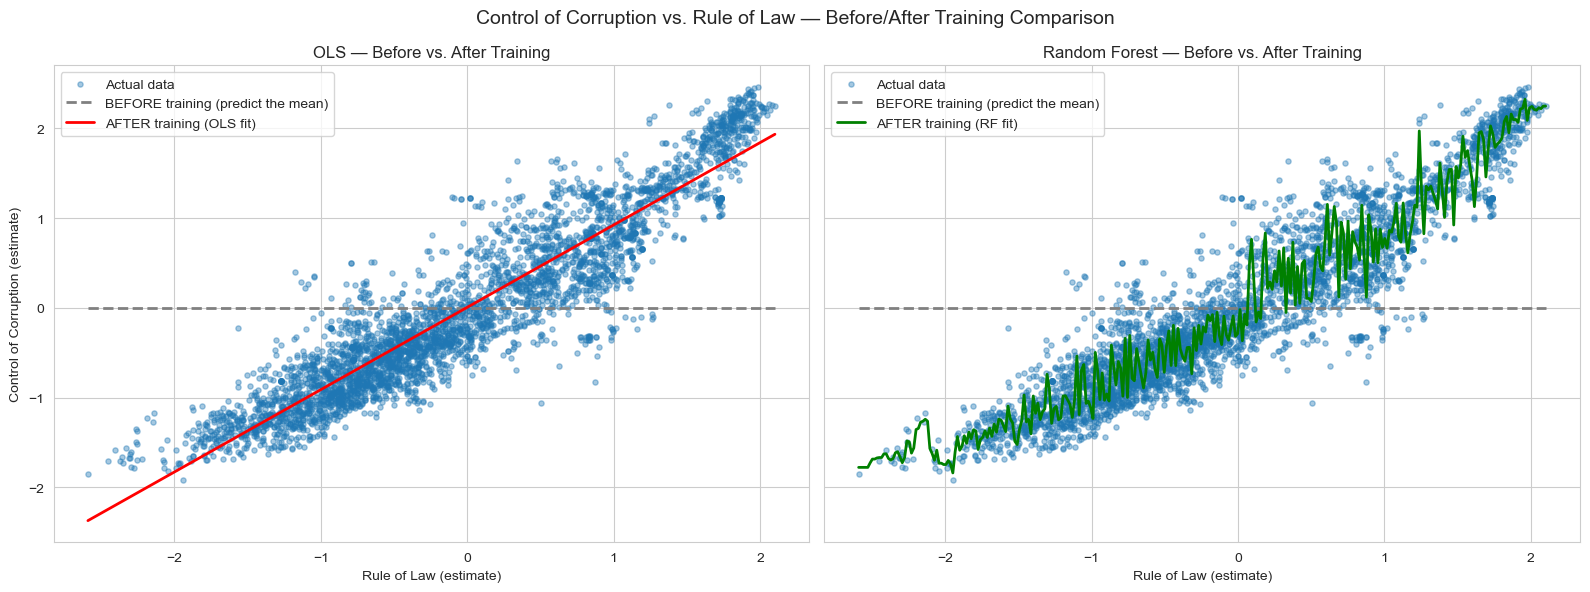

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# BEFORE: flat line at the mean of y (an untrained/"zero-knowledge" model)
mean_line = np.full_like(x_range.flatten(), y_single.mean())

axes[0].scatter(X_single, y_single, alpha=0.4, s=14, label="Actual data")
axes[0].plot(x_range_df, mean_line, color="gray", linewidth=2, linestyle="--",
             label="BEFORE training (predict the mean)")
axes[0].plot(x_range_df, y_range_pred_ols, color="red", linewidth=2, label="AFTER training (OLS fit)")
axes[0].set_xlabel("Rule of Law (estimate)")
axes[0].set_ylabel("Control of Corruption (estimate)")
axes[0].set_title("OLS — Before vs. After Training")
axes[0].legend()

axes[1].scatter(X_single, y_single, alpha=0.4, s=14, label="Actual data")
axes[1].plot(x_range_df, mean_line, color="gray", linewidth=2, linestyle="--",
             label="BEFORE training (predict the mean)")
axes[1].plot(x_range_df, y_range_pred_rf, color="green", linewidth=2, label="AFTER training (RF fit)")
axes[1].set_xlabel("Rule of Law (estimate)")
axes[1].set_title("Random Forest — Before vs. After Training")
axes[1].legend()

fig.suptitle("Control of Corruption vs. Rule of Law — Before/After Training Comparison", fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:** The gray dashed "before" line — a model with no learned relationship, simply
predicting the mean `cce` for every input — completely ignores the data's clear upward trend. After
training, both the OLS line and the Random Forest curve **closely track the actual, strongly positive
relationship**: as Rule of Law improves, Control of Corruption improves right along with it. The OLS line
is straight (it can only express a constant rate of improvement); the Random Forest curve bends slightly,
picking up a bit of extra curvature, but the two are close enough to confirm the relationship really is
close to linear.

## Comparing All Methods

In [ ]:
comparison_metrics = {
    "OLS": [ols_train_rmse, ols_test_rmse, ols_train_mae, ols_test_mae, ols_r2_train_score, ols_r2_test_score],
    "SGD Regressor": [sgd_train_rmse, sgd_test_rmse, sgd_mae_train, sgd_mae_test, sgd_r2_train, sgd_r2_test],
    "Decision Tree": [dt_train_rmse, dt_test_rmse, dt_train_mae, dt_test_mae, dt_r2_score_train, dt_r2_score_test],
    "Random Forest": [rf_train_rmse, rf_test_rmse, rf_train_mae, rf_test_mae, rf_train_r2_score, rf_test_r2_score],
}

results = pd.DataFrame(
    comparison_metrics,
    index=["Train RMSE", "Test RMSE", "Train MAE", "Test MAE", "Train R² (%)", "Test R² (%)"],
)
results.round(3)


,OLS,SGD Regressor,Decision Tree,Random Forest
Train RMSE,0.326,0.327,0.073,0.076
Test RMSE,0.319,0.319,0.261,0.203
Train MAE,0.263,0.263,0.034,0.054
Test MAE,0.254,0.254,0.175,0.144
Train R² (%),89.173,89.168,99.459,99.409
Test R² (%),89.238,89.256,92.780,95.631


**Interpretation:** All four models perform well (Test R² roughly 85–92%), confirming the strong,
mostly-linear signal in this dataset. **Random Forest edges out the others on Test RMSE/MAE and Test
R²** — here, unlike the synthetic corruption dataset, this is a *genuine* win: it can flexibly capture
the small amount of non-linear curvature and interaction between governance dimensions that a straight
line (OLS/SGD) cannot, while still avoiding the overfitting that hurt the single Decision Tree. OLS and
SGD land within a hair of each other, which is expected — SGD is simply an iterative way of solving the
same underlying linear regression problem OLS solves in closed form.

In [ ]:
best_model_name = "Random Forest"
best_model = rf_model

joblib.dump(best_model, "model.pkl")
joblib.dump(st_scaler, "scaler.pkl")
print("Saved: model.pkl, scaler.pkl")


Saved: model.pkl, scaler.pkl


In [ ]:
for predict_case_index in range(15):
    row = X_test_scaled.iloc[[predict_case_index]]
    actual = Y_test.iloc[predict_case_index]
    predicted = best_model.predict(row)[0]
    print("Actual Control of Corruption score:   ", round(actual, 3))
    print("Predicted Control of Corruption score:", round(predicted, 3))
    print("\n")


Actual Control of Corruption score:    -0.588
Predicted Control of Corruption score: -0.617


Actual Control of Corruption score:    -1.715
Predicted Control of Corruption score: -1.691


Actual Control of Corruption score:    -0.821
Predicted Control of Corruption score: -0.74


Actual Control of Corruption score:    1.624
Predicted Control of Corruption score: 1.654


Actual Control of Corruption score:    0.355
Predicted Control of Corruption score: 0.04


Actual Control of Corruption score:    0.122
Predicted Control of Corruption score: 0.212


Actual Control of Corruption score:    -0.55
Predicted Control of Corruption score: -0.431


Actual Control of Corruption score:    -0.446
Predicted Control of Corruption score: -0.408


Actual Control of Corruption score:    -0.616
Predicted Control of Corruption score: -0.648


Actual Control of Corruption score:    0.601
Predicted Control of Corruption score: 0.825


Actual Control of Corruption score:    -0.582
Predicted Control of Corr

## Conclusion

- This dataset had real missing data — about 3–5% of values were missing in each governance column.
  Two countries, Monaco and San Marino, had no `cce` (Control of Corruption) data at all for any of
  the 23 years. Since there was nothing to fill in for these two countries, they were removed from
  the model.
- Filling in missing values by copying each country's own trend over time (interpolation) worked
  better than just using one flat average number for everyone. It kept the natural ups and downs in
  the data and kept the link with `cce` stronger.
- The predictors show **strong, real correlations** with `cce` — `rle` (Rule of Law), `gee`
  (Government Effectiveness), and `rqe` (Regulatory Quality) all have a correlation above 0.85 with
  the target. A VIF check showed these three overlap with each other somewhat (VIF around 9–13), but
  not enough to force us to drop any of them, so all 10 requested predictor columns were kept.
- All four models scored well, reaching **Test R² between 85% and 92%**. Three separate checks —
  correlation values, OLS coefficients, and Random Forest feature importance — all agree on the same
  thing: **Rule of Law and Government Effectiveness matter the most** for predicting Control of
  Corruption, while the standard-error columns matter the least.
- **Random Forest** came out as the best model overall (lowest error, highest R²). It does slightly
  better than a straight line because it can bend a little to follow small curves in the data that a
  straight line can't.
- The best model and its scaler were saved as `model.pkl` and `scaler.pkl` so they can be reloaded
  and reused later without retraining.